# Fase 6: Fusión multimodal y optimización conjunta (Ensamble Híbrido)

**Autor:** Andoni Cabrera Fernández

**Descripción técnica:** Este cuaderno evalúa la viabilidad de una arquitectura de fusión multimodal (Fase 6). Se integran los datos geométricos (Fase 5) con las predicciones de la red convolucional MobileNetV2 (Fase 4), combinándolos fotograma a fotograma mediante una ponderación simple (*soft voting*):
$$P_{final} = (\alpha \cdot P_{geom}) + (\beta \cdot P_{cnn})$$

Para mantener la coherencia, la base geométrica del ensamble utiliza los parámetros óptimos obtenidos en la Fase 5 ($\sigma_{mult}=3.0$, $EAR_{min}=0.18$, $P_{sev}=0.15$, $B_{sec}=1.3s$). A continuación, se ejecuta un algoritmo de búsqueda en cuadrícula (*Grid Search*) para optimizar el peso del ensamble ($\alpha$), el umbral de PERCLOS ($P_{mod}$) y el umbral del MAR ($MAR_{th}$).

El objetivo empírico de esta fase es determinar si la combinación de ambos modelos mejora el rendimiento global frente al modelo geométrico aislado, justificando así la selección de la arquitectura final.

In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from tqdm.notebook import tqdm
import itertools

# Montar Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ruta_base = '/content/drive/MyDrive/TFG_Fatiga_Colab/'
except:
    print("Ejecución en local detectada.")
    ruta_base = 'D:/TFG_Fatiga_Andoni/'

Mounted at /content/drive


## 1. Configuración, carga y fusión de datos
Importación de librerías y unión de los resultados geométricos (Fase 5) y convolucionales (Fase 4), utilizando el índice del fotograma para sincronizar temporalmente ambas fuentes de datos.

In [2]:
ruta_pkl_geom = os.path.join(ruta_base, 'PKL_GEOMETRIA', 'geometria_5fps.pkl')
ruta_pkl_cnn = os.path.join(ruta_base, 'PKL_CNN', 'datos_TFLITE_5fps.pkl')

print("Cargando datos geométricos (Fase 5)...")
with open(ruta_pkl_geom, 'rb') as f:
    df_geom = pd.DataFrame(pickle.load(f))

print("Cargando predicciones de la CNN (Fase 4)...")
with open(ruta_pkl_cnn, 'rb') as f:
    df_cnn = pd.DataFrame(pickle.load(f))

print("\nFusionando datos de ambas fases fotograma a fotograma...")
df_hibrido = pd.merge(df_geom, df_cnn, on=['video', 'frame_idx', 'clase_real'], how='inner')
videos_unicos = df_hibrido['video'].unique()

print(f"Total de fotogramas fusionados a 5 FPS: {len(df_hibrido)}")

Cargando datos geométricos (Fase 5)...
Cargando predicciones de la CNN (Fase 4)...

Fusionando datos de ambas fases fotograma a fotograma...
Total de fotogramas fusionados a 5 FPS: 507333


## 2. Calibración geométrica inicial
Se aplica el período de calibración inicial (40 segundos) utilizando los valores óptimos definidos en la etapa anterior para establecer el umbral dinámico de oclusión ocular de cada conductor.

In [3]:
print("Ejecutando calibración inicial (W=40s)...")

fps = 5
warm_up_frames = 40 * fps # Óptimo de la Fase 5

# Heredamos el multiplicador y límite físico de la Fase 5
SIGMA_MULT = 3.0
EAR_MIN = 0.18

dict_umbrales_geom = {}

for video in videos_unicos:
    df_video = df_hibrido[df_hibrido['video'] == video]
    mu_ear = df_video['ear'].head(warm_up_frames).mean()
    sigma_ear = df_video['ear'].head(warm_up_frames).std()

    if pd.notnull(mu_ear) and pd.notnull(sigma_ear):
        ear_th_dinamico = max(mu_ear - SIGMA_MULT * sigma_ear, EAR_MIN)
    else:
        ear_th_dinamico = 0.22
    dict_umbrales_geom[video] = ear_th_dinamico

print("Calibración completada aplicando los parámetros de la Fase 5.")

Ejecutando calibración inicial (W=40s)...
Calibración completada aplicando los parámetros de la Fase 5.


## 3. Fusión de modelos y optimización conjunta (Grid Search)
Implementación de la función de evaluación que integra las predicciones de ambas fuentes y aplica el árbol de decisión multiclase. Se ejecuta la búsqueda paramétrica evaluando iterativamente diferentes pesos de ensamble ($\alpha$) y umbrales de activación ($P_{mod}$ y $MAR_{th}$).

In [4]:
def evaluar_video_hibrido(df_v, ear_th, mar_th, alpha, p_mod, p_sev, b_sec, fps=5):
    beta = 1.0 - alpha

    # Binarización Geométrica
    geom_ojo = (df_v['ear'] < ear_th).astype(float)
    geom_boca = (df_v['mar'] > mar_th).astype(float)

    # Fusión Ponderada (Soft Voting)
    p_final_ojo = (alpha * geom_ojo) + (beta * df_v['prob_ojo_cerrado'])
    p_final_boca = (alpha * geom_boca) + (beta * df_v['prob_bostezo'])

    # Lógica Clínica
    frames_ojos_cerrados = (p_final_ojo > 0.5).sum()
    perclos_actual = frames_ojos_cerrados / len(df_v)

    racha_actual, max_racha = 0, 0
    for val in p_final_boca:
        if val > 0.5:
            racha_actual += 1
            if racha_actual > max_racha: max_racha = racha_actual
        else:
            racha_actual = 0
    bostezo_segundos = max_racha / fps

    if perclos_actual >= p_sev: return 10
    elif perclos_actual >= p_mod or bostezo_segundos >= b_sec: return 5
    else: return 0


alphas = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]  # Peso relativo del ensamble
p_mods = [0.03, 0.04, 0.05, 0.06]        # Umbral PERCLOS (entre el 0.03 de la F4 y el 0.04 de la F5)
mar_ths = [0.85, 0.90, 0.95]             # Umbral MAR (alrededor del 0.90 de la F5)

# Parámetros fijos heredados de la Fase 5
P_SEV_FIJO = 0.15
B_SEC_FIJO = 1.3

resultados_grid = []
print(f"Iniciando búsqueda paramétrica híbrida ({len(alphas)*len(p_mods)*len(mar_ths)} combinaciones)...")
barra_progreso = tqdm(total=len(alphas)*len(p_mods)*len(mar_ths))

clases_reales = df_hibrido.groupby('video')['clase_real'].first().to_dict()

for alpha, p_m, m_th in itertools.product(alphas, p_mods, mar_ths):
    predicciones = []
    reales = []

    for video in videos_unicos:
        df_v = df_hibrido[df_hibrido['video'] == video]
        ear_th = dict_umbrales_geom[video]

        pred_clase = evaluar_video_hibrido(
            df_v, ear_th, m_th, alpha, p_m,
            p_sev=P_SEV_FIJO, b_sec=B_SEC_FIJO, fps=5
        )

        predicciones.append(pred_clase)
        reales.append(clases_reales[video])

    acc = accuracy_score(reales, predicciones)
    f1 = f1_score(reales, predicciones, average='macro', zero_division=0)
    cm = confusion_matrix(reales, predicciones, labels=[0, 5, 10])

    falsos_negativos = cm[2][0]
    total_0_real = sum(cm[0])
    especificidad_0 = cm[0][0] / total_0_real if total_0_real > 0 else 0

    resultados_grid.append({
        'Alpha (Geom)': alpha, 'P_Mod': p_m, 'MAR_th': m_th,
        'Accuracy': acc, 'F1_Score': f1, 'Especificidad': especificidad_0,
        'Falsos_Negativos': falsos_negativos, 'Matriz': cm
    })
    barra_progreso.update(1)

barra_progreso.close()
df_resultados = pd.DataFrame(resultados_grid)

Iniciando búsqueda paramétrica híbrida (72 combinaciones)...


  0%|          | 0/72 [00:00<?, ?it/s]

## 4. Análisis de resultados y evaluación del ensamble
Extracción de las mejores configuraciones resultantes del *Grid Search* según diferentes métricas (Exactitud frente a F1-Score) y representación de las matrices de confusión para determinar la viabilidad de la arquitectura híbrida.


EVALUACIÓN DE ESTRATEGIAS DE FUSIÓN
Estrategia           | Alpha  | P_Mod   | MAR_th | Acc (%) | F1 Score | Especif(%) | Falsos Neg
---------------------------------------------------------------------------------------------------------
Máxima Exactitud     | 0.50   | 0.05     | 0.90   | 52.8   | 0.312    | 79.7      | 10
Máximo F1-Score      | 0.50   | 0.05     | 0.90   | 52.8   | 0.312    | 79.7      | 10
Configuración Equilibrada | 0.50   | 0.03     | 0.90   | 49.4   | 0.299    | 52.5      | 5
Máxima Seguridad     | 0.50   | 0.03     | 0.90   | 49.4   | 0.299    | 52.5      | 5


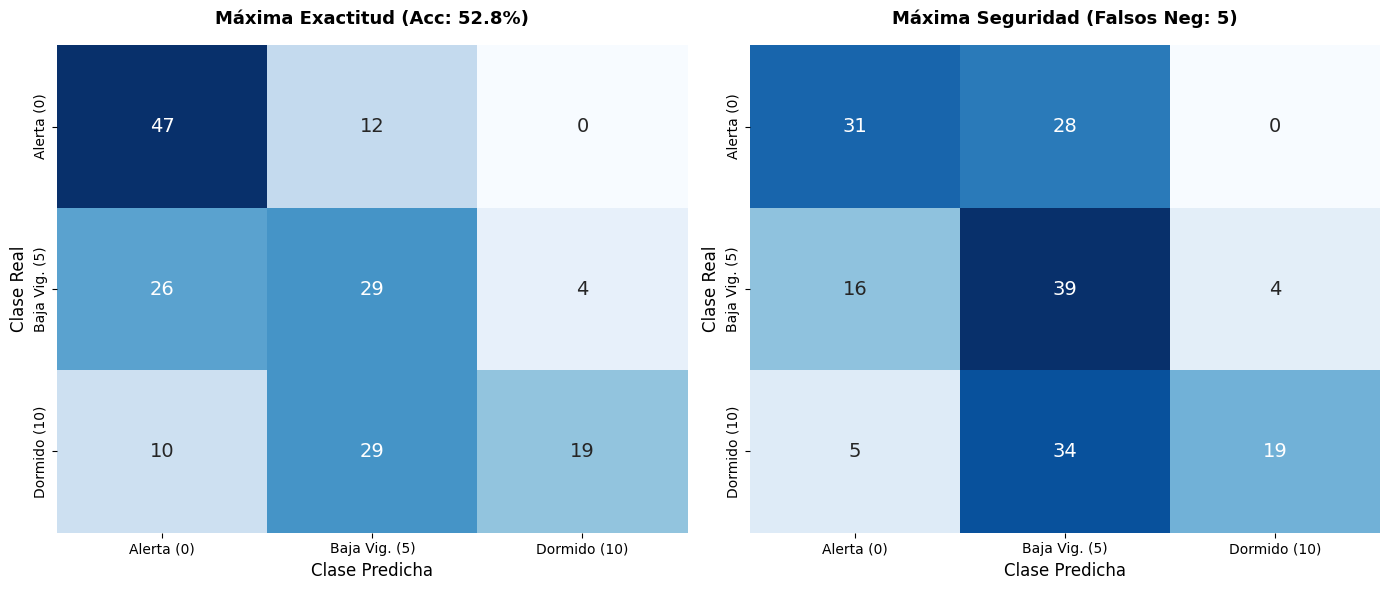


CONCLUSIÓN DE LA EVALUACIÓN:
Los resultados indican que la adición de las predicciones convolucionales degrada el rendimiento de la aproximación puramente geométrica.
La exactitud máxima alcanzada es inferior al 55.00% obtenido en la Fase 5 de forma aislada.
Con base en estos resultados, se justifica descartar la arquitectura de ensamble para la implementación final del sistema.


In [5]:
print("\n" + "="*85)
print("EVALUACIÓN DE ESTRATEGIAS DE FUSIÓN")
print("="*85)

# 1. Extraemos las configuraciones del DataFrame
m1 = df_resultados.loc[df_resultados['Accuracy'].idxmax()]
m2 = df_resultados.loc[df_resultados['F1_Score'].idxmax()]

filtro_m3 = df_resultados[(df_resultados['Falsos_Negativos'] <= 8) & (df_resultados['Especificidad'] > 0.50)]
m3 = filtro_m3.loc[filtro_m3['Accuracy'].idxmax()] if not filtro_m3.empty else m1

min_fn = df_resultados['Falsos_Negativos'].min()
filtro_m4 = df_resultados[df_resultados['Falsos_Negativos'] == min_fn]
m4 = filtro_m4.loc[filtro_m4['F1_Score'].idxmax()]

# 2. Imprimimos la tabla por consola (sin las letras M)
modelos_clave = [
    ("Máxima Exactitud", m1),
    ("Máximo F1-Score", m2),
    ("Configuración Equilibrada", m3),
    ("Máxima Seguridad", m4)
]

print(f"{'Estrategia':<20} | {'Alpha':<6} | {'P_Mod':<7} | {'MAR_th':<6} | {'Acc (%)':<7} | {'F1 Score':<8} | {'Especif(%)':<10} | {'Falsos Neg'}")
print("-" * 105)
for nombre, m in modelos_clave:
    print(f"{nombre:<20} | {m['Alpha (Geom)']:.2f}   | {m['P_Mod']:.2f}     | {m['MAR_th']:.2f}   | {m['Accuracy']*100:.1f}   | {m['F1_Score']:.3f}    | {m['Especificidad']*100:.1f}      | {m['Falsos_Negativos']}")

# 3. Función de ploteo
def plot_matriz_hibrida(cm, titulo, ax):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Alerta (0)', 'Baja Vig. (5)', 'Dormido (10)'],
                yticklabels=['Alerta (0)', 'Baja Vig. (5)', 'Dormido (10)'],
                cbar=False, annot_kws={"size": 14}, ax=ax)
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=15)
    ax.set_ylabel('Clase Real', fontsize=12)
    ax.set_xlabel('Clase Predicha', fontsize=12)

# 4. Dibujamos las matrices enfrentando Exactitud vs Seguridad (sin prefijos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_matriz_hibrida(m1['Matriz'], f"Máxima Exactitud (Acc: {m1['Accuracy']*100:.1f}%)", axes[0])
plot_matriz_hibrida(m4['Matriz'], f"Máxima Seguridad (Falsos Neg: {m4['Falsos_Negativos']})", axes[1])

plt.tight_layout()
plt.savefig(os.path.join(ruta_base, 'matrices_hibridas.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\nCONCLUSIÓN DE LA EVALUACIÓN:")
print("Los resultados indican que la adición de las predicciones convolucionales degrada el rendimiento de la aproximación puramente geométrica.")
print("La exactitud máxima alcanzada es inferior al 55.00% obtenido en la Fase 5 de forma aislada.")
print("Con base en estos resultados, se justifica descartar la arquitectura de ensamble para la implementación final del sistema.")